# Notebook 03: Oscillation Pattern Detection

**Detection Vector 1 (Weight: 20% of Manipulation Score)**

This notebook analyzes whether Trump's Truth Social posts create "pump-and-dump" style
oscillation patterns in oil prices:
- Escalation post → price spike → de-escalation post → price drop → repeat

**Research Questions:**
1. Are oil price reversals more common on days with Trump posts?
2. Do Trump's posts show a systematic oscillation pattern (escalation ↔ de-escalation)?
3. Is there evidence of intentional volatility creation?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import timedelta

plt.style.use('seaborn-v0_8-whitegrid')

# Color scheme
COLORS = {
    'escalation': '#d62728',
    'de_escalation': '#2ca02c',
    'neutral': '#7f7f7f',
    'no_posts': '#cccccc',
    'oil_price': '#1f77b4',
    'fabrication': '#ff7f0e'
}

# Load data
master = pd.read_csv('../data/processed/master_dataset.csv')
master['date'] = pd.to_datetime(master['date'])
posts = pd.read_csv('../data/processed/posts_cleaned.csv')
posts['timestamp'] = pd.to_datetime(posts['timestamp'])
posts['date'] = pd.to_datetime(posts['date'])

# Filter to trading days for price analysis
trading = master[master['is_trading_day'] == 1].copy().reset_index(drop=True)
print(f'Trading days: {len(trading)}')
print(f'Oil-related post days: {(trading["oil_post_count"] > 0).sum()}')

Trading days: 305
Oil-related post days: 283


## 1. Volatility Comparison: Post Days vs. Non-Post Days

If posts are designed to move markets, we should see higher price volatility
on days when oil-related posts are published.

In [2]:
# Compare absolute daily returns on post days vs non-post days
trading['abs_brent_change'] = trading['brent_pct_change'].abs()

post_days = trading[trading['oil_post_count'] > 0]
no_post_days = trading[trading['oil_post_count'] == 0]

print('=== VOLATILITY COMPARISON ===')
print(f'\nDays with oil-related posts ({len(post_days)} days):')
print(f'  Mean absolute return: {post_days["abs_brent_change"].mean():.2f}%')
print(f'  Median absolute return: {post_days["abs_brent_change"].median():.2f}%')
print(f'  Max absolute return: {post_days["abs_brent_change"].max():.2f}%')

print(f'\nDays without oil-related posts ({len(no_post_days)} days):')
print(f'  Mean absolute return: {no_post_days["abs_brent_change"].mean():.2f}%')
print(f'  Median absolute return: {no_post_days["abs_brent_change"].median():.2f}%')
print(f'  Max absolute return: {no_post_days["abs_brent_change"].max():.2f}%')

ratio = post_days['abs_brent_change'].mean() / no_post_days['abs_brent_change'].mean()
print(f'\nVolatility ratio (post/no-post): {ratio:.2f}x')

=== VOLATILITY COMPARISON ===

Days with oil-related posts (283 days):
  Mean absolute return: 1.70%
  Median absolute return: 1.29%
  Max absolute return: 12.53%

Days without oil-related posts (22 days):
  Mean absolute return: 0.99%
  Median absolute return: 0.89%
  Max absolute return: 3.67%

Volatility ratio (post/no-post): 1.71x


/var/folders/s4/1tybbv891h91ytkv6d9z0bz00000gn/T/ipykernel_20922/4241437923.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=trading, x='post_category', y='abs_brent_change', ax=axes[0],


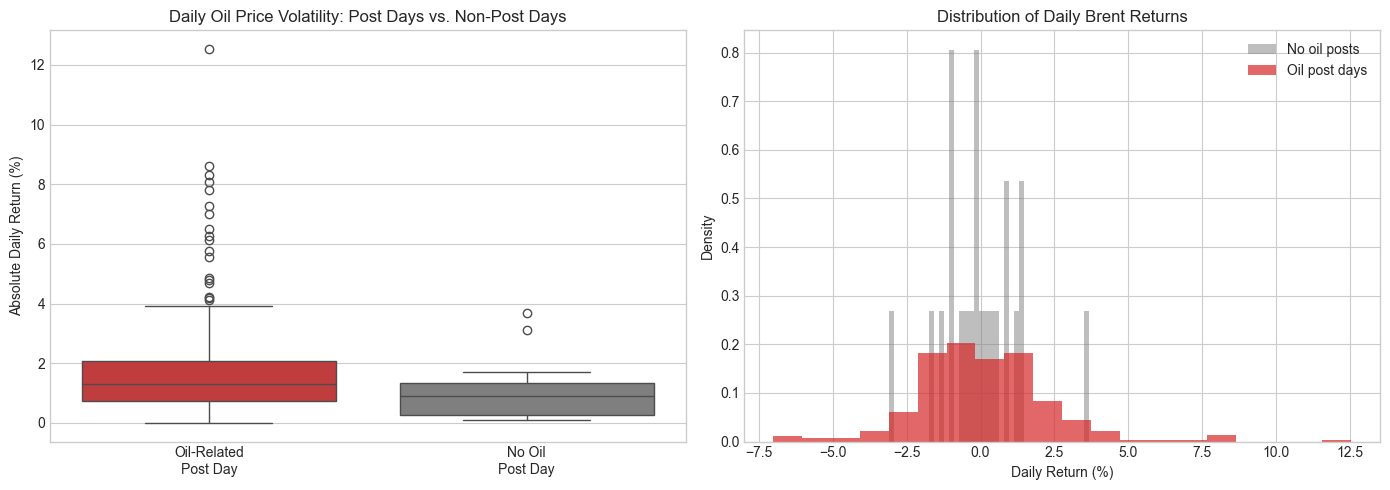

In [3]:
# Visualization 1: Box plots comparing daily returns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of absolute returns
trading['post_category'] = trading['oil_post_count'].apply(
    lambda x: 'Oil-Related\nPost Day' if x > 0 else 'No Oil\nPost Day'
)

sns.boxplot(data=trading, x='post_category', y='abs_brent_change', ax=axes[0],
            palette=[COLORS['escalation'], COLORS['neutral']])
axes[0].set_title('Daily Oil Price Volatility: Post Days vs. Non-Post Days', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Absolute Daily Return (%)')

# Histogram of returns by category
axes[1].hist(no_post_days['brent_pct_change'].dropna(), bins=40, alpha=0.5, 
             label='No oil posts', color=COLORS['neutral'], density=True)
axes[1].hist(post_days['brent_pct_change'].dropna(), bins=20, alpha=0.7, 
             label='Oil post days', color=COLORS['escalation'], density=True)
axes[1].set_title('Distribution of Daily Brent Returns', fontsize=12)
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/fig_volatility_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Price Reversal Detection

A reversal is when the oil price moves significantly in one direction, then reverses
within a short window. This is the signature of pump-and-dump manipulation.

In [4]:
def detect_reversals(df, price_col='brent_pct_change', threshold=2.0, window=3):
    """
    Detect price reversals: a move >threshold% followed by an opposite move
    within 'window' trading days.
    
    Returns DataFrame of reversal events.
    """
    reversals = []
    pct = df[price_col].values
    dates = df['date'].values
    
    for i in range(len(pct) - window):
        if pd.isna(pct[i]) or abs(pct[i]) < threshold:
            continue
        
        initial_direction = np.sign(pct[i])
        
        # Look for reversal in next 'window' days
        for j in range(1, window + 1):
            if i + j >= len(pct) or pd.isna(pct[i + j]):
                continue
            
            if np.sign(pct[i + j]) == -initial_direction and abs(pct[i + j]) >= threshold * 0.5:
                reversals.append({
                    'date': dates[i],
                    'initial_move_pct': pct[i],
                    'reversal_pct': pct[i + j],
                    'reversal_day': j,
                    'reversal_date': dates[i + j],
                    'swing_magnitude': abs(pct[i]) + abs(pct[i + j])
                })
                break  # Only count first reversal
    
    return pd.DataFrame(reversals)

reversals = detect_reversals(trading)
print(f'Price reversals detected (>{2}% move + reversal within 3 days): {len(reversals)}')

if len(reversals) > 0:
    reversals['date'] = pd.to_datetime(reversals['date'])
    print(f'Average swing magnitude: {reversals["swing_magnitude"].mean():.2f}%')
    print(f'\nLargest swings:')
    print(reversals.nlargest(10, 'swing_magnitude')[['date', 'initial_move_pct', 'reversal_pct', 'swing_magnitude']].to_string())

Price reversals detected (>2% move + reversal within 3 days): 55
Average swing magnitude: 5.75%

Largest swings:
         date  initial_move_pct  reversal_pct  swing_magnitude
51 2026-03-04         -2.065322      8.619421        10.684743
49 2026-03-02          8.300617     -2.065322        10.365939
52 2026-03-05          8.619421     -1.451849        10.071270
50 2026-03-03          7.819782     -2.065322         9.885104
45 2026-02-02         -6.269896      3.381571         9.651467
7  2025-04-04         -5.762338      3.761949         9.524287
53 2026-03-06          8.070888     -1.451849         9.522737
6  2025-03-31          3.400723     -6.121393         9.522116
35 2025-10-23          6.486834     -2.274115         8.760948
19 2025-06-13          7.284020     -1.250000         8.534020


In [5]:
# Check if reversals coincide with oil-related posts
if len(reversals) > 0:
    reversals_with_posts = reversals.merge(
        trading[['date', 'oil_post_count', 'dominant_direction']],
        on='date', how='left'
    )
    
    post_reversals = reversals_with_posts[reversals_with_posts['oil_post_count'] > 0]
    no_post_reversals = reversals_with_posts[reversals_with_posts['oil_post_count'] == 0]
    
    print(f'Reversals on post days: {len(post_reversals)} / {len(reversals)} ({len(post_reversals)/len(reversals)*100:.1f}%)')
    print(f'Reversals on non-post days: {len(no_post_reversals)} / {len(reversals)} ({len(no_post_reversals)/len(reversals)*100:.1f}%)')
    
    # Compare to base rate
    post_day_pct = (trading['oil_post_count'] > 0).mean() * 100
    print(f'\nBase rate: {post_day_pct:.1f}% of trading days have oil posts')
    print(f'Reversal rate: {len(post_reversals)/len(reversals)*100:.1f}% of reversals happen on post days')

Reversals on post days: 53 / 55 (96.4%)
Reversals on non-post days: 2 / 55 (3.6%)

Base rate: 92.8% of trading days have oil posts
Reversal rate: 96.4% of reversals happen on post days


## 3. Oscillation Score Calculation

For each day, calculate an oscillation score (0-100) based on:
- Whether the dominant direction contradicts the previous post-day's direction
- Whether a price reversal occurred within 3 days
- The magnitude of the swing

In [6]:
def calculate_oscillation_scores(df):
    """
    Calculate oscillation score (0-100) for each day.
    
    High score = post direction contradicts recent previous posts,
    and a price reversal occurred.
    """
    scores = []
    oil_post_days = df[df['oil_post_count'] > 0].copy()
    
    for i in range(len(df)):
        row = df.iloc[i]
        score = 0
        
        if row['oil_post_count'] == 0:
            scores.append(0)
            continue
        
        current_direction = row['dominant_direction']
        if current_direction in ['neutral', 'no_posts']:
            scores.append(0)
            continue
        
        # Find previous oil post day within 5 days
        lookback = df.iloc[max(0, i-5):i]
        prev_post_days = lookback[lookback['oil_post_count'] > 0]
        
        if len(prev_post_days) == 0:
            scores.append(10)  # Post but no recent comparison
            continue
        
        prev_direction = prev_post_days.iloc[-1]['dominant_direction']
        
        # Check for direction reversal
        opposite = (
            (current_direction == 'escalation' and prev_direction == 'de_escalation') or
            (current_direction == 'de_escalation' and prev_direction == 'escalation')
        )
        
        if opposite:
            # Direction reversed — check price impact
            price_change = abs(row['brent_pct_change']) if pd.notna(row['brent_pct_change']) else 0
            
            if price_change > 5:
                score = 100
            elif price_change > 2:
                score = 75
            elif price_change > 1:
                score = 50
            else:
                score = 30
        else:
            score = 10  # Same direction as previous post
        
        scores.append(score)
    
    df['oscillation_score'] = scores
    return df

trading = calculate_oscillation_scores(trading)

high_osc = trading[trading['oscillation_score'] >= 50]
print(f'Days with high oscillation score (>=50): {len(high_osc)}')
if len(high_osc) > 0:
    print(high_osc[['date', 'brent_pct_change', 'dominant_direction', 'oscillation_score']].to_string())

Days with high oscillation score (>=50): 51
          date  brent_pct_change dominant_direction  oscillation_score
12  2025-01-20         -1.614069      de_escalation                 50
27  2025-02-10          2.075522         escalation                 75
29  2025-02-12         -2.923374      de_escalation                 75
36  2025-02-21         -2.690058      de_escalation                 75
38  2025-02-25         -2.376819         escalation                 75
40  2025-02-27          2.068309         escalation                 75
57  2025-03-24          1.817181      de_escalation                 50
59  2025-03-26          1.111412      de_escalation                 50
62  2025-03-31          3.400723         escalation                 75
87  2025-05-08          3.166971      de_escalation                 75
92  2025-05-15         -2.351692         escalation                 75
93  2025-05-16          1.305158      de_escalation                 50
103 2025-06-02          3.467040 

## 4. Oil Price Timeline with Post Markers

The hero visualization: Brent crude oil price over time with Trump's oil-related
posts marked by direction (escalation = red, de-escalation = green).

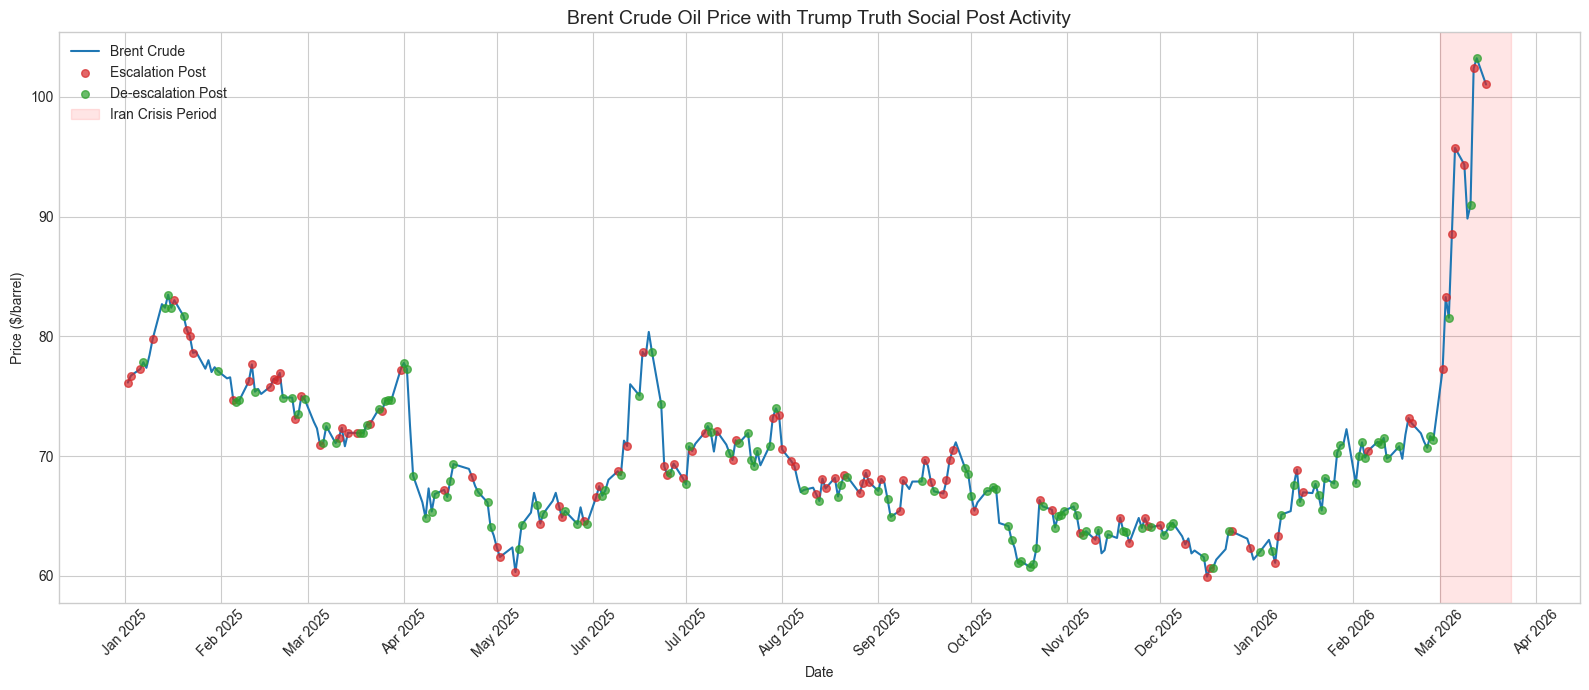

In [7]:
fig, ax = plt.subplots(figsize=(16, 7))

# Plot oil price
ax.plot(trading['date'], trading['brent_close'], 
        color=COLORS['oil_price'], linewidth=1.5, label='Brent Crude', zorder=2)

# Add post markers
for direction, color, label in [
    ('escalation', COLORS['escalation'], 'Escalation Post'),
    ('de_escalation', COLORS['de_escalation'], 'De-escalation Post'),
]:
    mask = trading['dominant_direction'] == direction
    subset = trading[mask]
    if len(subset) > 0:
        ax.scatter(subset['date'], subset['brent_close'], 
                   color=color, s=30, alpha=0.7, label=label, zorder=3)

# Highlight March 2026 Iran crisis period
crisis_start = pd.Timestamp('2026-03-01')
crisis_end = pd.Timestamp('2026-03-24')
ax.axvspan(crisis_start, crisis_end, alpha=0.1, color='red', label='Iran Crisis Period')

ax.set_title('Brent Crude Oil Price with Trump Truth Social Post Activity', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($/barrel)')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/fig_oil_price_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

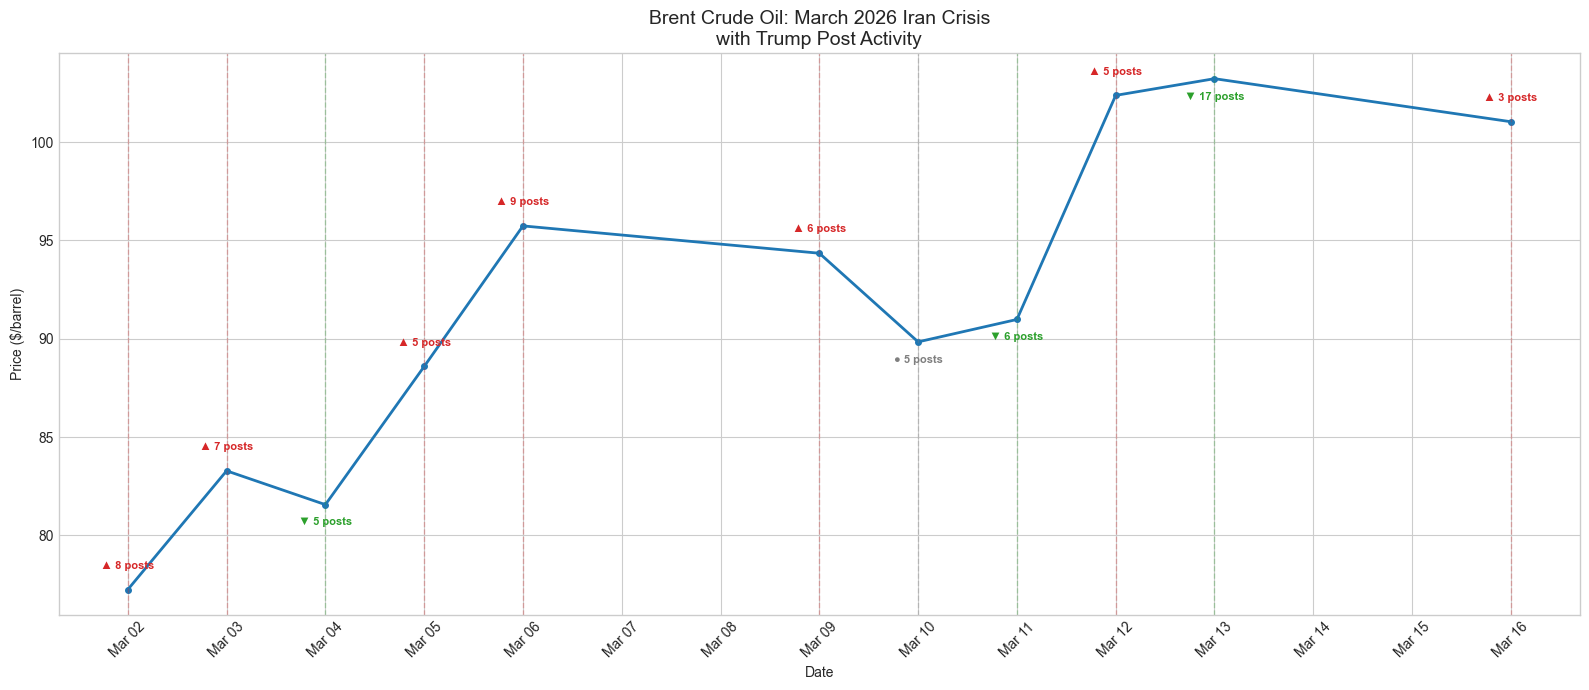

In [8]:
# Zoomed view: March 2026 Iran crisis
march = trading[(trading['date'] >= '2026-03-01') & (trading['date'] <= '2026-03-24')].copy()

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(march['date'], march['brent_close'], 
        color=COLORS['oil_price'], linewidth=2, marker='o', markersize=4, label='Brent Crude')

# Mark post days with arrows and labels
oil_post_days_march = march[march['oil_post_count'] > 0]

for _, row in oil_post_days_march.iterrows():
    direction = row['dominant_direction']
    color = COLORS.get(direction, COLORS['neutral'])
    
    # Vertical line on post day
    ax.axvline(row['date'], color=color, alpha=0.3, linestyle='--', linewidth=1)
    
    # Arrow pointing to price
    if pd.notna(row['brent_close']):
        symbol = '▲' if direction == 'escalation' else '▼' if direction == 'de_escalation' else '●'
        ax.annotate(
            f'{symbol} {row["oil_post_count"]} posts',
            xy=(row['date'], row['brent_close']),
            xytext=(0, 15 if direction == 'escalation' else -15),
            textcoords='offset points',
            fontsize=8, color=color, fontweight='bold',
            ha='center'
        )

ax.set_title('Brent Crude Oil: March 2026 Iran Crisis\nwith Trump Post Activity', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($/barrel)')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/fig_march_crisis_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Save oscillation scores back to master dataset
osc_scores = trading[['date', 'oscillation_score']].copy()
osc_scores.to_csv('../data/processed/oscillation_scores.csv', index=False)
print(f'Saved oscillation scores for {len(osc_scores)} trading days')
print('\nNext step: Run notebook 04 for Gemini AI classification.')

Saved oscillation scores for 305 trading days

Next step: Run notebook 04 for Gemini AI classification.
